In [1]:
import japanize_matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
# parameters
# 母集団
mu = 0
sigma = 1

# サンプルサイズ
n_samples = 30

# 有意水準
alpha = 0.05

# シミュレーション回数
n_simulations = 10000

In [3]:
def get_sample(
    mu: float,
    sigma: float,
    n_samples: int,
    n_simulations: int,
    seed: int=42,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.normal(mu, sigma, (n_simulations, n_samples))

In [4]:
def t_test(samples: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    t_statistics = []
    p_values = []
    for sample in samples:
        result = stats.ttest_1samp(sample, popmean=0)
        t_statistics.append(result.statistic)
        p_values.append(result.pvalue)
    
    return np.array(t_statistics), np.array(p_values)

In [5]:
samples = get_sample(mu, sigma, n_samples, n_simulations)
t_statistics, p_values = t_test(samples)

In [6]:
# check reject
rejected = p_values < alpha
reject_mean = rejected.mean()

In [7]:
print(f"シミュレーション回数: {n_simulations}")
print(f"有意水準: {alpha}")
print(f"H0 を棄却した割合: {rejected.mean():.4f}")

シミュレーション回数: 10000
有意水準: 0.05
H0 を棄却した割合: 0.0495


In [16]:
def plot_sample_mean(samples: np.ndarray) -> None:
    sample_means = samples.mean(axis=1)

    plt.hist(
        sample_means,
        bins=50,
        density=True,
        alpha=0.7
    )

    plt.axvline(0, linestyle="--", label="母平均 μ=0")
    plt.xlabel("標本平均")
    plt.ylabel("密度")
    plt.title("標本平均のシミュレーション")
    plt.legend()
    plt.show()

In [17]:
def plot_dist_p_values(p_values: np.ndarray, alpha: float) -> None:
    plt.hist(
        p_values,
        bins=50,
        density=True,
        alpha=0.7
    )

    plt.axvline(
        alpha,
        linestyle="--",
        label=f"有意水準 α={alpha}"
    )
    plt.xlabel("p-value")
    plt.ylabel("密度")
    plt.title("p値のシミュレーション")
    plt.legend()
    plt.show()

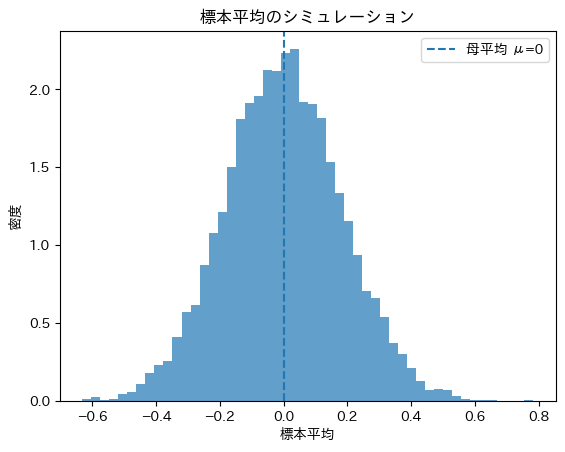

In [18]:
plot_sample_mean(samples)

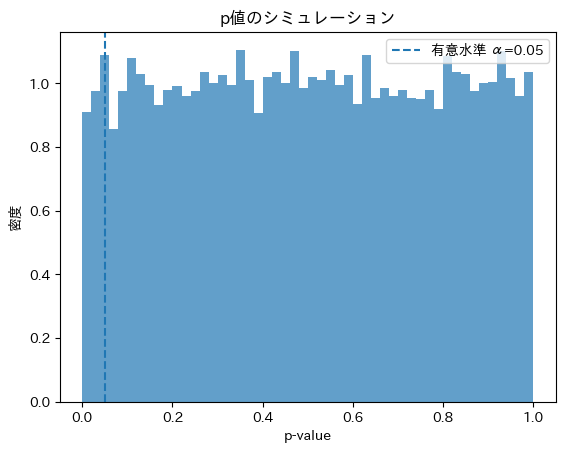

In [19]:
plot_dist_p_values(p_values, alpha)